In [1]:
import pandas as pd
import sqlite3 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect("delhivery.db")
df = pd.read_sql("SELECT  *  FROM shipments", conn)
# df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')
print(df.shape)
df.head()

(149936, 22)


,shipment_id,order_date,dispatch_date,expected_delivery_date,actual_delivery_date,product_category,product_sub_category,package_size,weight_kg,order_value,...,destination_tier,distance_band,payment_type,customer_type,attempt_count,is_sale_season,delivery_status,is_delayed,is_rto,actual_delivery_days
0,SHP125670,2023-07-15,2023-07-16,2023-07-21,2023-07-22,Clothing & Apparel,Footwear,Medium,0.827,3192.83,...,Tier 3,Long,COD,Returning,1,0,Delivered on Time,0,0,6.0
1,SHP133151,2021-12-12,2021-12-16,2021-12-17,None,Pharma & Health,Personal Care,Small,0.721,1447.02,...,Metro,Medium,COD,Returning,1,0,Pending,0,0,NaN
2,SHP135896,2021-07-29,2021-07-29,2021-08-04,2021-08-05,Grocery & FMCG,Rice & Pulses,Large,1.196,497.09,...,Tier 2,Long,Prepaid,Returning,2,0,Delayed,1,0,7.0
3,SHP101190,2024-08-14,2024-08-14,2024-08-21,2024-08-24,Grocery & FMCG,Cooking Essentials,Medium,3.966,517.02,...,Tier 3,Long,Prepaid,Returning,1,1,Delayed,1,0,10.0
4,SHP166912,2023-10-24,2023-10-26,2023-10-30,None,Furniture & Home Decor,Bed,Oversized,46.399,27659.12,...,Tier 2,Medium,Prepaid,Returning,1,1,RTO,0,1,NaN


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149936 entries, 0 to 149935
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shipment_id             149936 non-null  object 
 1   order_date              149936 non-null  object 
 2   dispatch_date           149936 non-null  object 
 3   expected_delivery_date  149936 non-null  object 
 4   actual_delivery_date    109111 non-null  object 
 5   product_category        149936 non-null  object 
 6   product_sub_category    149936 non-null  object 
 7   package_size            149936 non-null  object 
 8   weight_kg               149936 non-null  float64
 9   order_value             149936 non-null  float64
 10  origin_city             149936 non-null  object 
 11  destination_city        149936 non-null  object 
 12  destination_tier        149936 non-null  object 
 13  distance_band           149936 non-null  object 
 14  payment_type        

,weight_kg,order_value,attempt_count,is_sale_season,is_delayed,is_rto,actual_delivery_days
count,149936.000000,149936.000000,149936.000000,149936.000000,149936.000000,149936.000000,109111.000000
mean,4.786903,8540.794937,1.442989,0.404879,0.184999,0.195597,7.507043
std,14.833497,18392.194179,0.678255,0.490870,0.388298,0.396661,3.699359
min,0.010000,50.060000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,0.467000,705.417500,1.000000,0.000000,0.000000,0.000000,5.000000
50%,0.942000,1473.955000,1.000000,0.000000,0.000000,0.000000,7.000000
75%,2.218000,3731.665000,2.000000,1.000000,0.000000,0.000000,10.000000
max,149.963000,119969.460000,3.000000,1.000000,1.000000,1.000000,21.000000


## 1. EDA 

In [4]:
date_cols = ['order_date','dispatch_date','expected_delivery_date','actual_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col],errors='coerce')

df[date_cols].dtypes

order_date                datetime64[ns]
dispatch_date             datetime64[ns]
expected_delivery_date    datetime64[ns]
actual_delivery_date      datetime64[ns]
dtype: object

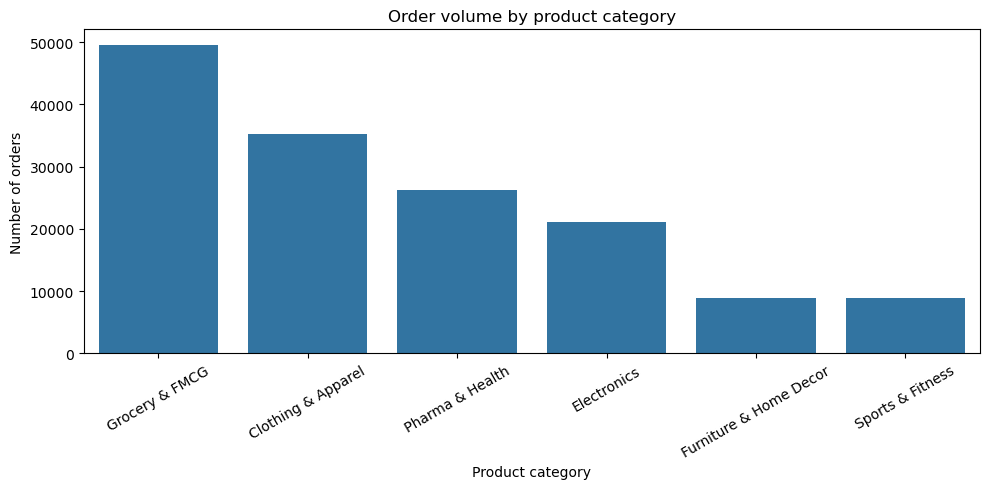

In [5]:
plt .figure(figsize=(10,5))
sns.countplot(data=df , x='product_category', order=df['product_category'].value_counts().index)
plt.title('Order volume by product category')
plt.xlabel('Product category')
plt.ylabel('Number of orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

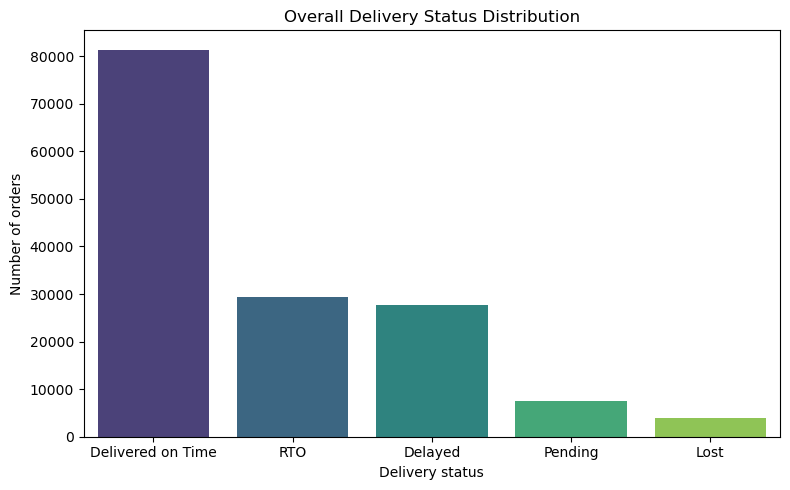

In [6]:
plt .figure(figsize=(8,5))
sns.countplot(data=df , x='delivery_status', order=df['delivery_status'].value_counts().index, palette ='viridis')
plt.title('Overall Delivery Status Distribution')
plt.xlabel('Delivery status')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

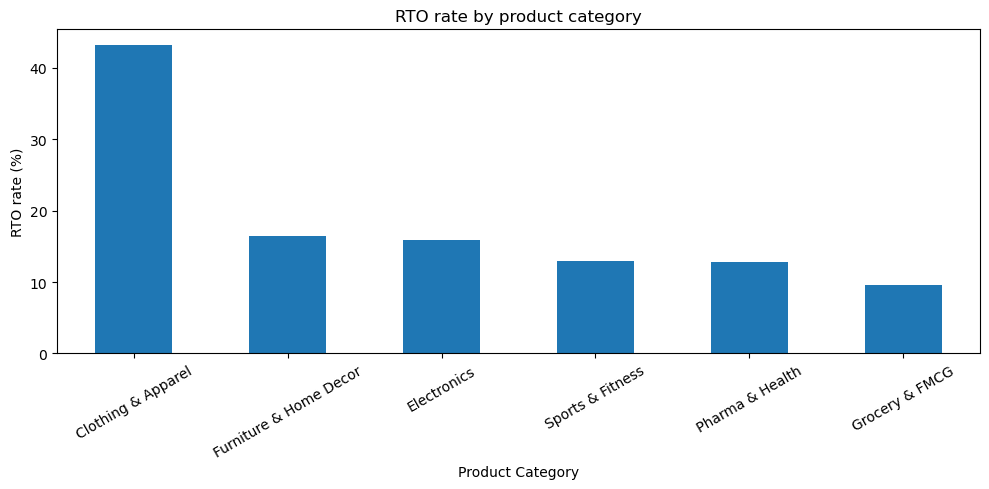

In [7]:
rto_by_cat = df.groupby('product_category')['is_rto'].mean().sort_values(ascending=False)*100

plt.figure(figsize=(10,5))
rto_by_cat.plot(kind='bar')
plt.title('RTO rate by product category')
plt.xlabel('Product Category')
plt.ylabel('RTO rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

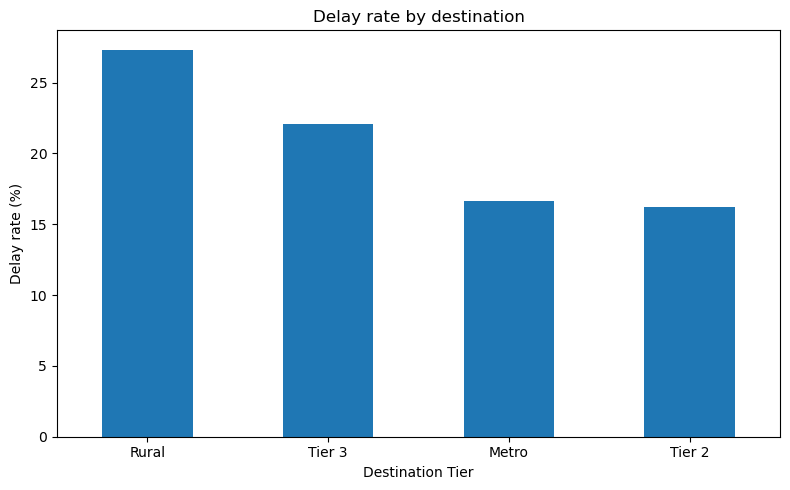

In [8]:
delay_by_tier = df.groupby('destination_tier')['is_delayed'].mean().sort_values(ascending=False)*100

plt.figure(figsize=(8,5))
delay_by_tier.plot(kind='bar')
plt.title('Delay rate by destination')
plt.xlabel('Destination Tier')
plt.ylabel('Delay rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

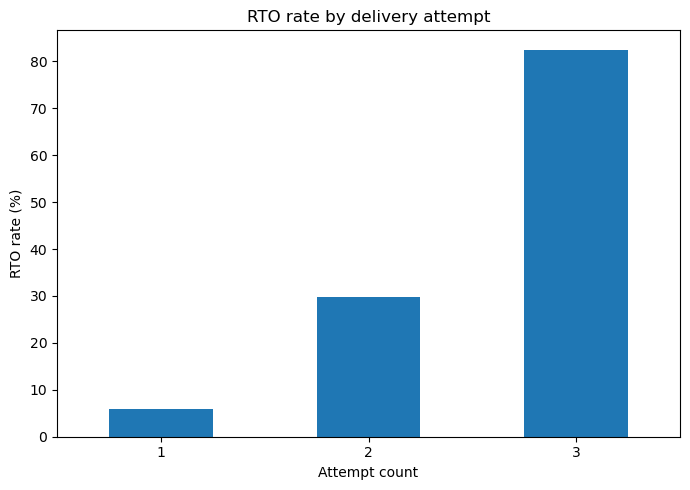

In [9]:
rto_by_attempt = df.groupby('attempt_count')['is_rto'].mean()*100

plt.figure(figsize=(7,5))
rto_by_attempt.plot(kind='bar')
plt.title('RTO rate by delivery attempt')
plt.xlabel('Attempt count')
plt.ylabel('RTO rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

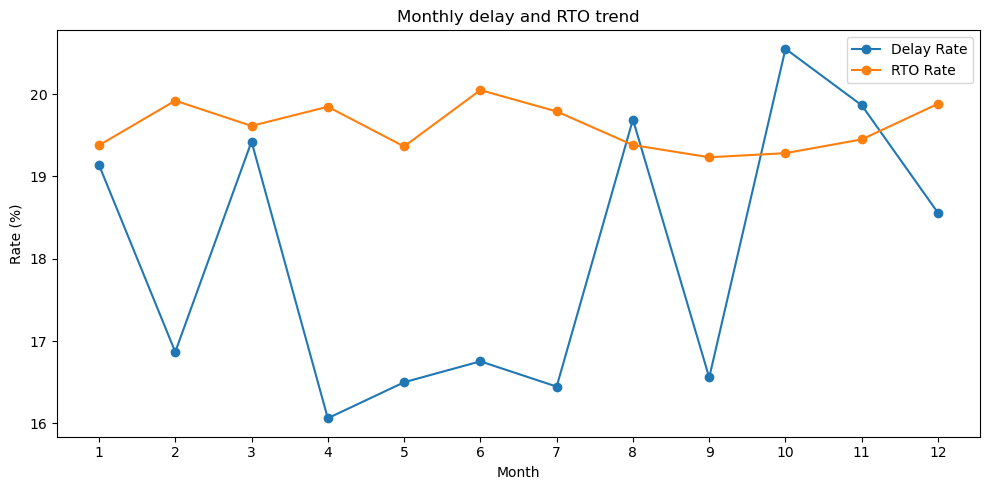

In [10]:
df['order_month']=df['order_date'].dt.month

monthly_trend = df.groupby('order_month')[['is_delayed','is_rto']].mean()*100

plt.figure(figsize=(10,5))
plt.plot(monthly_trend.index,monthly_trend['is_delayed'],marker='o', label='Delay Rate') 
plt.plot(monthly_trend.index,monthly_trend['is_rto'],marker='o', label='RTO Rate')
plt.title('Monthly delay and RTO trend')
plt.xlabel('Month')
plt.ylabel('Rate (%)')
plt.xticks(range(1,13))
plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

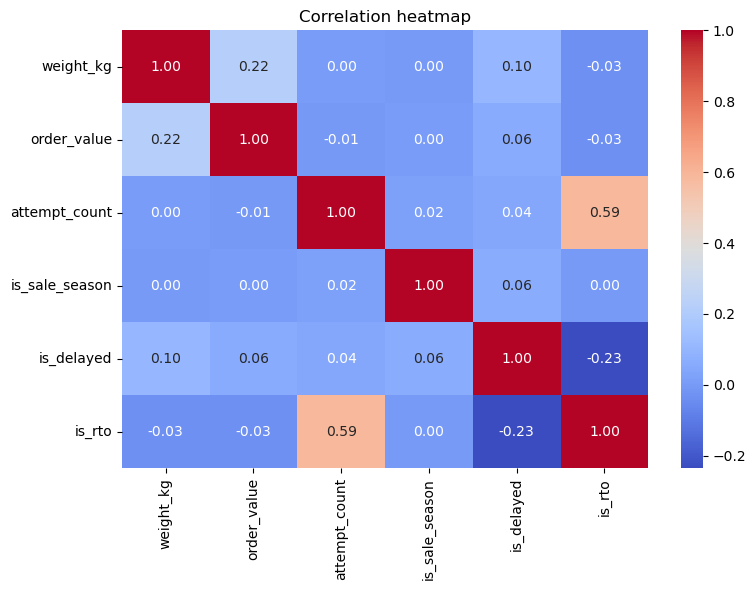

In [11]:
numeric_cols = ['weight_kg','order_value','attempt_count','is_sale_season','is_delayed','is_rto']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True , cmap='coolwarm', fmt='.2f')
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show

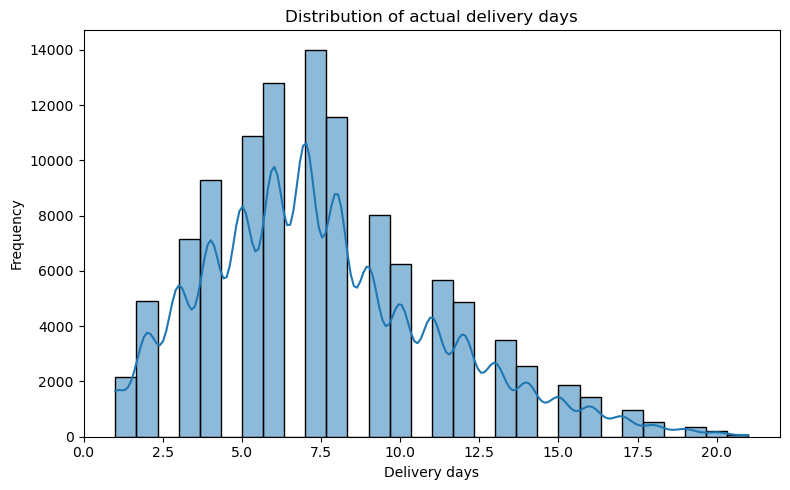

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['actual_delivery_days'].dropna(), bins=30, kde=True)
plt.title('Distribution of actual delivery days')
plt.xlabel('Delivery days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

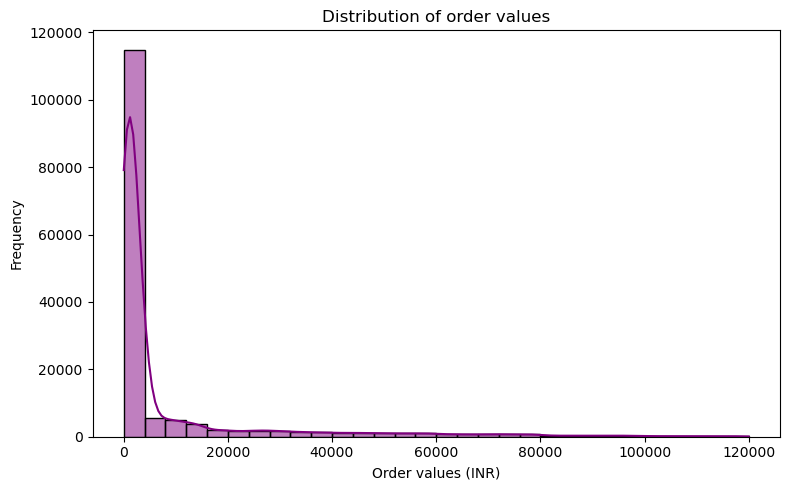

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['order_value'], bins=30, kde=True , color='purple')
plt.title('Distribution of order values')
plt.xlabel('Order values (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

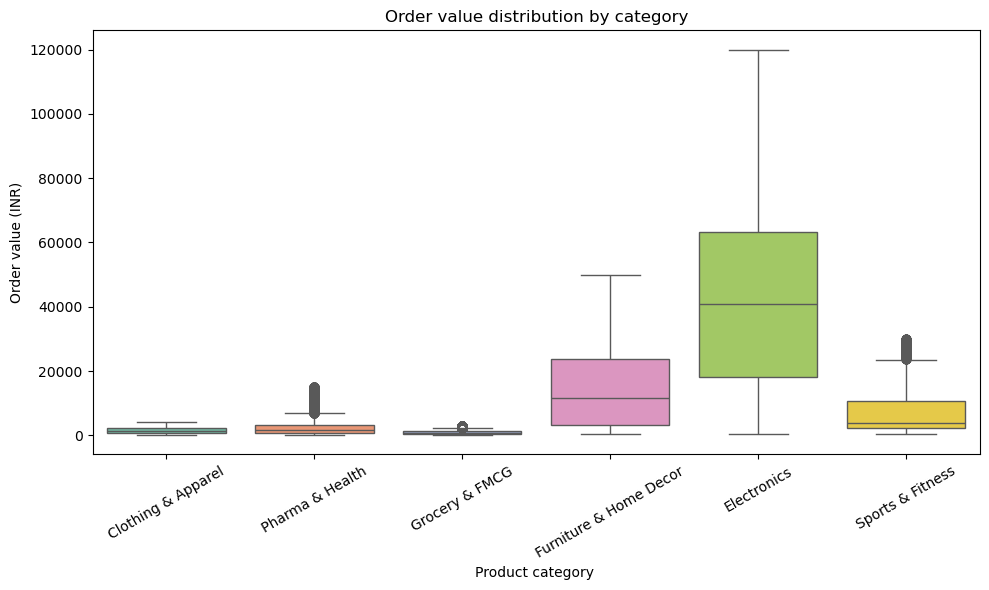

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df , x='product_category', y='order_value' , palette='Set2')
plt.title('Order value distribution by category')
plt.xlabel('Product category ')
plt.ylabel('Order value (INR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

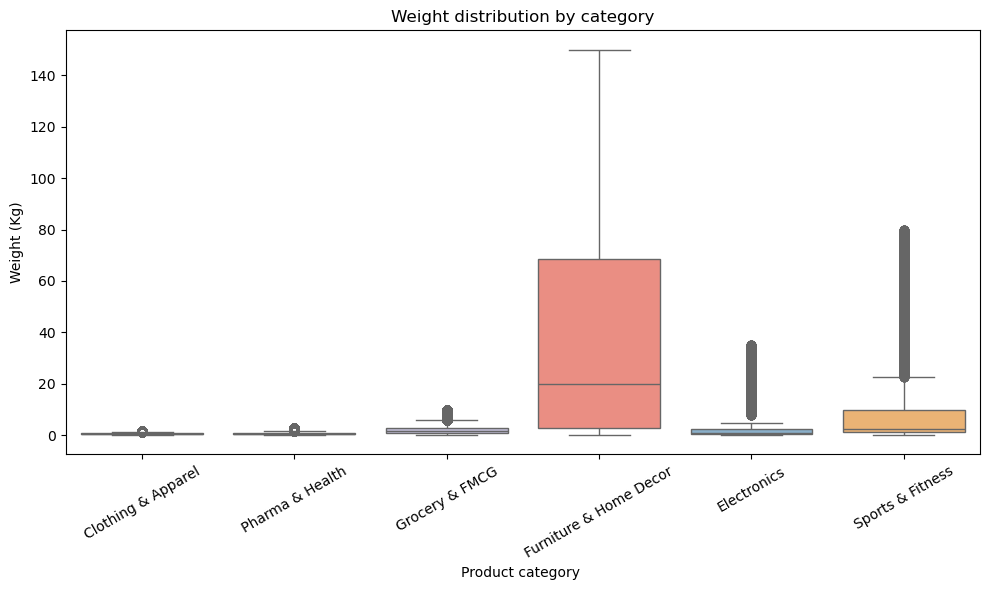

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df , x='product_category', y='weight_kg' , palette='Set3')
plt.title('Weight distribution by category')
plt.xlabel('Product category ')
plt.ylabel('Weight (Kg)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
print("weight_kg - most common exact value:")
print(df['weight_kg'].value_counts().head(10))

print("\norder_value - most common exact value:")
print(df['order_value'].value_counts().head(10))

weight_kg - most common exact value:
weight_kg
2.680    260
0.760    230
1.090    184
0.010    166
0.303    161
0.336    158
0.332    153
0.370    152
0.305    150
0.394    150
Name: count, dtype: int64

order_value - most common exact value:
order_value
976.43      158
1687.04     113
3138.20      93
43001.10     61
14680.66     28
7329.43      21
560.06        6
356.67        6
743.49        6
578.82        6
Name: count, dtype: int64


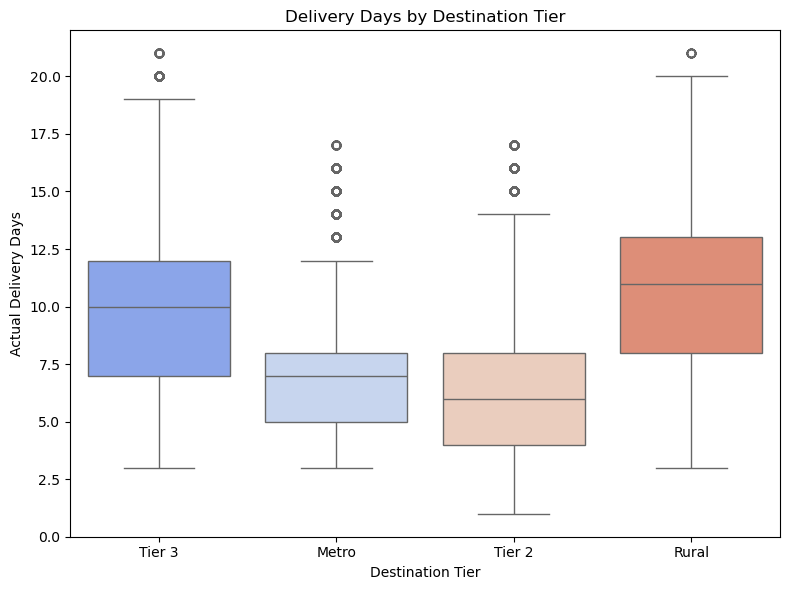

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='destination_tier', y='actual_delivery_days', palette='coolwarm')
plt.title('Delivery Days by Destination Tier')
plt.xlabel('Destination Tier')
plt.ylabel('Actual Delivery Days')
plt.tight_layout()
plt.show()

In [18]:
df['actual_delivery_days'].value_counts().head(10)

actual_delivery_days
7.0     14003
6.0     12788
8.0     11560
5.0     10881
4.0      9303
9.0      8020
3.0      7158
10.0     6258
11.0     5665
2.0      4924
Name: count, dtype: int64

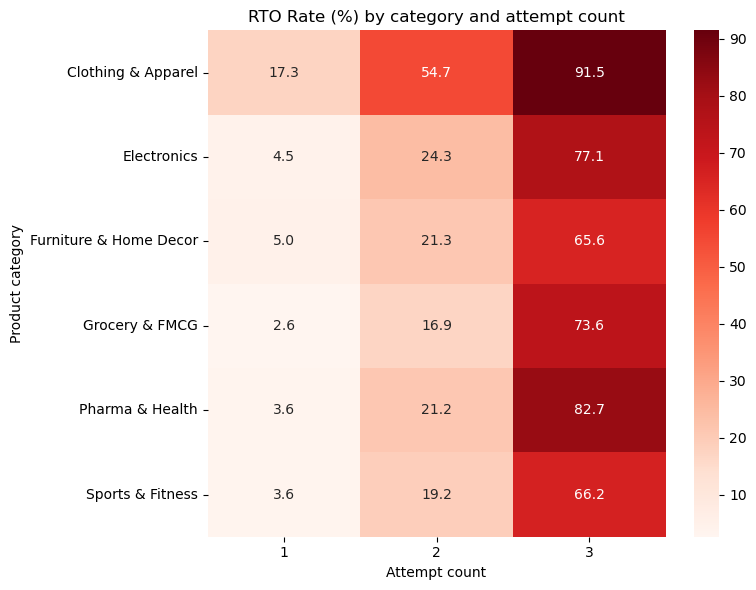

In [19]:
pivot = df.pivot_table(values='is_rto', index='product_category',columns='attempt_count', aggfunc='mean')*100

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('RTO Rate (%) by category and attempt count')
plt.xlabel('Attempt count')
plt.ylabel('Product category')
plt.tight_layout()
plt.show()

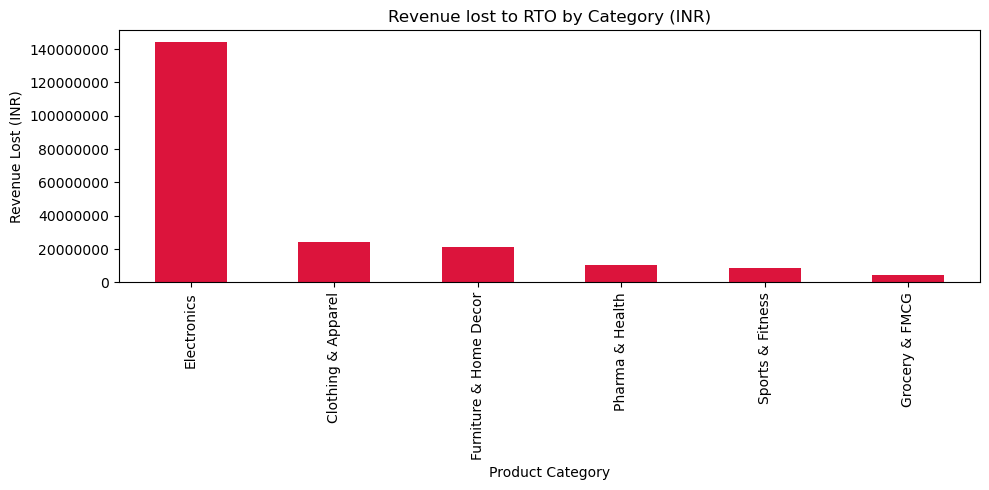

In [20]:
revenue_lost = df[df['is_rto']==1].groupby('product_category')['order_value'].sum().sort_values(ascending=False)

plt .figure(figsize=(10,5))
revenue_lost.plot(kind='bar',color='crimson')
plt.title('Revenue lost to RTO by Category (INR)')
plt.xlabel('Product Category')
plt.ylabel('Revenue Lost (INR)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

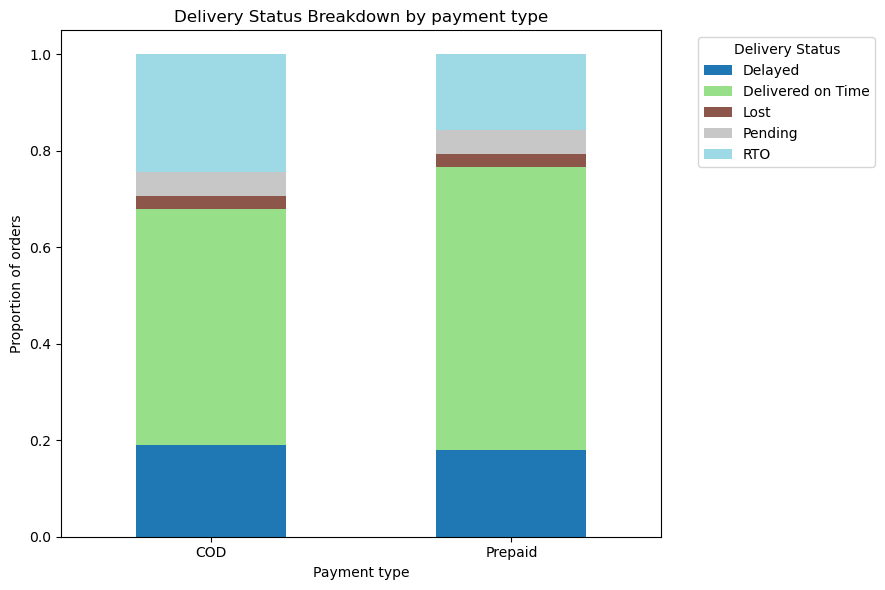

In [21]:
pd.crosstab(df['payment_type'], df['delivery_status'], normalize='index').plot(
    kind='bar',stacked=True, figsize=(9,6), colormap='tab20'
)
plt.title('Delivery Status Breakdown by payment type')
plt.xlabel('Payment type')
plt.ylabel('Proportion of orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

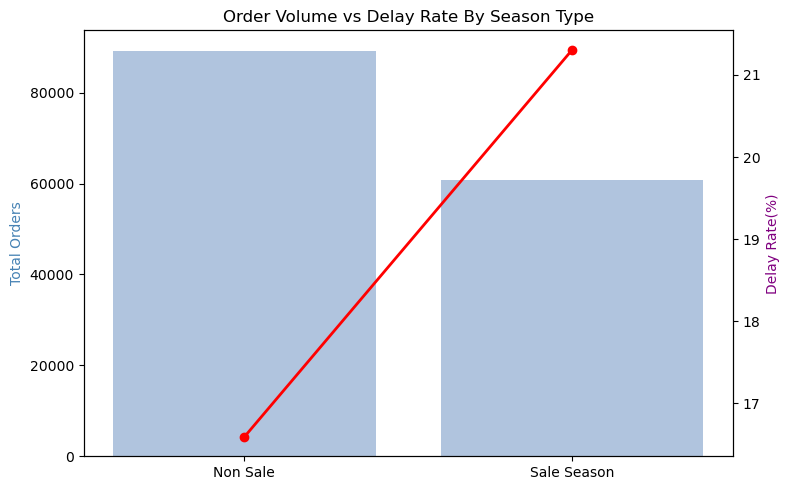

In [22]:
season_stats = df.groupby('is_sale_season').agg(
    total_orders = ('shipment_id', 'count'),
    delay_rate = ('is_delayed','mean')
)
season_stats['delay_rate'] = season_stats['delay_rate']*100

fig, ax1 = plt.subplots(figsize = (8,5))
ax1.bar(['Non Sale', 'Sale Season'], season_stats['total_orders'], color='lightsteelblue')
ax1.set_ylabel('Total Orders', color = 'steelblue')

ax2 = ax1.twinx()
ax2.plot(['Non Sale', 'Sale Season'], season_stats['delay_rate'], color='red', marker = 'o', linewidth = 2)
ax2.set_ylabel('Delay Rate(%)', color = 'purple')

plt.title('Order Volume vs Delay Rate By Season Type')
plt.tight_layout()
plt.show()

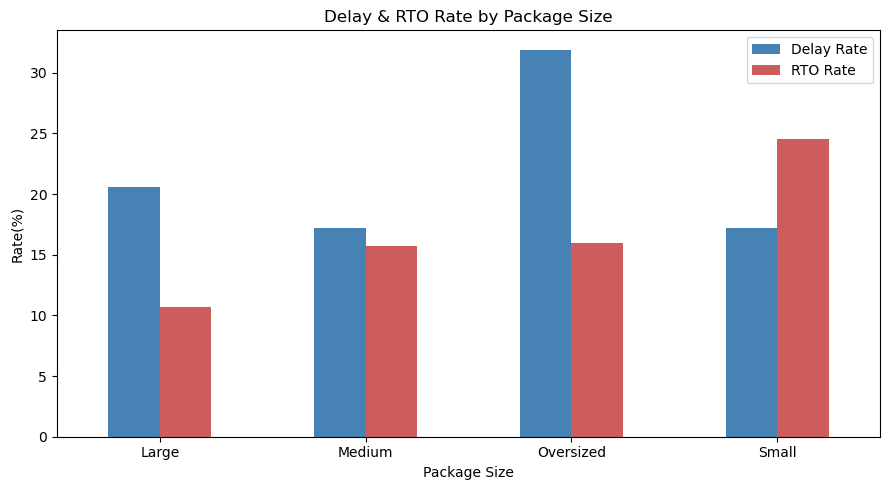

In [23]:
pkg_stats = df.groupby('package_size')[['is_delayed', 'is_rto']].mean()*100

pkg_stats.plot(kind = 'bar', figsize = (9,5), color = ['steelblue','indianred'])
plt.title('Delay & RTO Rate by Package Size')
plt.xlabel('Package Size')
plt.ylabel('Rate(%)')
plt.xticks(rotation = 0)
plt.legend(['Delay Rate', 'RTO Rate'])
plt.tight_layout()
plt.show()

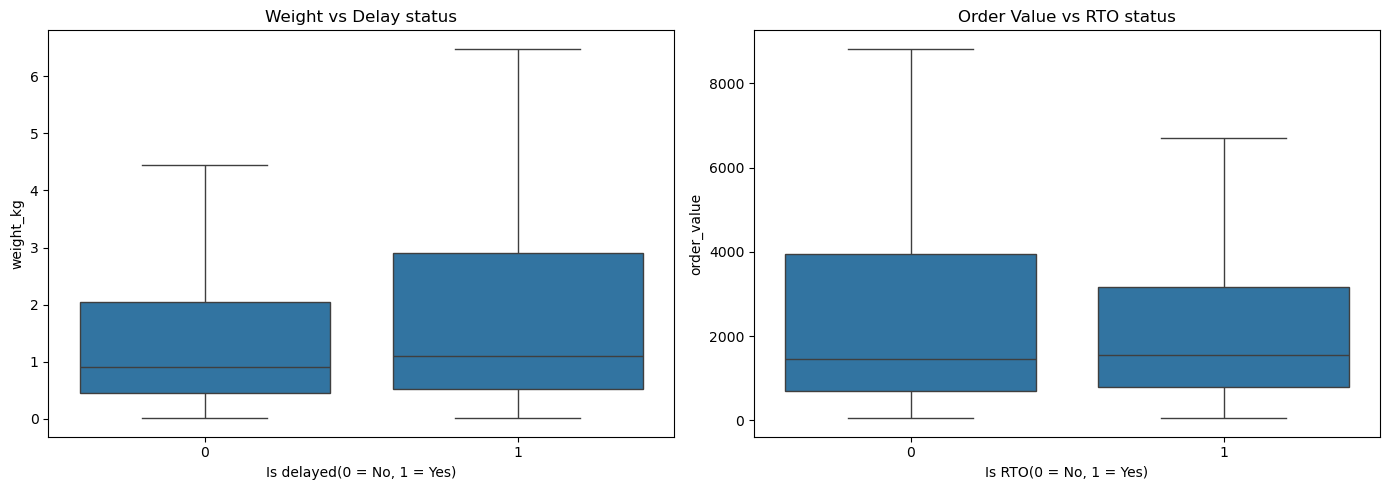

In [24]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

sns.boxplot(data = df, x = 'is_delayed', y = 'weight_kg', ax = axes[0], showfliers = False )
axes[0].set_title('Weight vs Delay status')
axes[0].set_xlabel('Is delayed(0 = No, 1 = Yes)')

sns.boxplot(data = df, x = 'is_rto', y = 'order_value', ax = axes[1], showfliers = False)
axes[1].set_title('Order Value vs RTO status')
axes[1].set_xlabel('Is RTO(0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()


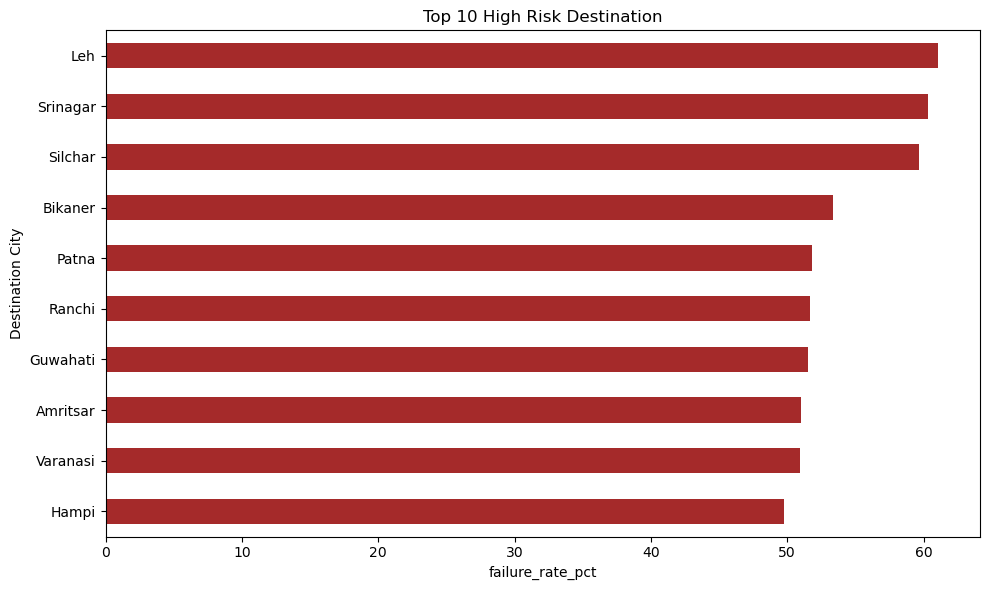

In [25]:
city_stats = df.groupby('destination_city').agg(
    total_orders = ('shipment_id', 'count'),
    rto = ('is_rto', 'sum'),
    delayed = ('is_delayed', 'sum'),
    lost = ('delivery_status', lambda x: (x == 'Lost').sum())
)

city_stats['failure_rate_pct'] = (city_stats['rto'] + city_stats['delayed'] + city_stats['lost'])*100/ city_stats['total_orders']

top10 = city_stats.sort_values('failure_rate_pct', ascending = False).head(10)

plt.figure(figsize = (10,6))
top10['failure_rate_pct'].plot(kind = 'barh', color = 'brown')
plt.title('Top 10 High Risk Destination')
plt.xlabel('failure_rate_pct')
plt.ylabel('Destination City')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [26]:
df_model = df.copy()
df_model.shape

(149936, 23)

In [27]:
#Extracted useful features from date columns

df_model['order_day_of_week'] = df_model['order_date'].dt.dayofweek
df_model['order_month'] = df_model['order_date'].dt.month
df_model['is_weekend'] = df_model['order_day_of_week'].isin([5,6]).astype(int)

df_model[['order_date','order_day_of_week','order_month','is_weekend']].head()

,order_date,order_day_of_week,order_month,is_weekend
0,2023-07-15,5,7,1
1,2021-12-12,6,12,1
2,2021-07-29,3,7,0
3,2024-08-14,2,8,0
4,2023-10-24,1,10,0


In [28]:
df['payment_type'].apply(repr).unique()
# print(df['customer_type'].unique())

array(["'COD'", "'Prepaid'"], dtype=object)

In [29]:
# Removed (') from the characters

df_model['payment_type'] = df['payment_type'].astype(str).str.strip("'")
df_model['customer_type'] = df['customer_type'].astype(str).str.strip("'")

print(df_model['payment_type'].unique())
print(df_model['customer_type'].unique())

['COD' 'Prepaid']
['Returning' 'New']


In [30]:
# Encoded categorical columns into numbers - (Binary)

df_model['payment_type'] = df_model['payment_type'].map({'COD':0, 'Prepaid':1})
df_model['customer_type'] = df_model['customer_type'].map({'New':0, 'Returning':1})
df_model['is_sale_season'] = df_model['is_sale_season'].astype(int)

df_model[['payment_type','customer_type','is_sale_season']].head()

,payment_type,customer_type,is_sale_season
0,0,1,0
1,0,1,0
2,1,1,0
3,1,1,1
4,1,1,1


In [31]:
# One hot encoding for Multi-value 

categorical_cols = ['product_category','destination_tier','distance_band','package_size']

df_model = pd.get_dummies(df_model , columns=categorical_cols, drop_first=True)

df_model.shape

(149936, 35)

In [32]:
# destination_cities

df_model = pd.get_dummies(df_model, columns=['destination_city'],drop_first=True)
df_model.shape

(149936, 66)

In [33]:
df_model.head()

,shipment_id,order_date,dispatch_date,expected_delivery_date,actual_delivery_date,product_sub_category,weight_kg,order_value,origin_city,payment_type,...,destination_city_Nagpur,destination_city_Nashik,destination_city_Patna,destination_city_Pune,destination_city_Ranchi,destination_city_Silchar,destination_city_Srinagar,destination_city_Surat,destination_city_Varanasi,destination_city_Vijayawada
0,SHP125670,2023-07-15,2023-07-16,2023-07-21,2023-07-22,Footwear,0.827,3192.83,Mumbai,0,...,False,False,False,False,False,False,False,False,False,False
1,SHP133151,2021-12-12,2021-12-16,2021-12-17,NaT,Personal Care,0.721,1447.02,Mumbai,0,...,False,False,False,False,False,False,False,False,False,False
2,SHP135896,2021-07-29,2021-07-29,2021-08-04,2021-08-05,Rice & Pulses,1.196,497.09,Mumbai,1,...,False,False,False,False,False,False,False,False,False,False
3,SHP101190,2024-08-14,2024-08-14,2024-08-21,2024-08-24,Cooking Essentials,3.966,517.02,Mumbai,1,...,False,False,False,False,False,False,False,False,False,False
4,SHP166912,2023-10-24,2023-10-26,2023-10-30,NaT,Bed,46.399,27659.12,Mumbai,1,...,False,False,False,False,False,False,False,False,False,False


In [34]:
# Drop columns that shouldnt be used as model inputs
drop_cols = ['shipment_id', 'order_date', 'dispatch_date','expected_delivery_date','actual_delivery_date' ]
df_model=df_model.drop(columns=drop_cols)
df_model.shape

(149936, 61)

In [35]:
# dropped attempt_count 
df_model= df_model.drop(columns=['attempt_count'])
df_model.shape

(149936, 60)

In [36]:
# Final check for leftover 
print(df_model.isnull().sum().sum())
print(df_model.dtypes.value_counts())

40825
bool       46
int64       4
int32       4
object      3
float64     3
Name: count, dtype: int64


In [37]:
df_model.isnull().sum()[df_model.isnull().sum()>0]

actual_delivery_days    40825
dtype: int64

In [38]:
df_model.select_dtypes(include='object').columns

Index(['product_sub_category', 'origin_city', 'delivery_status'], dtype='object')

In [39]:
df_model['product_sub_category'].nunique()

30

In [40]:
# # Dropped both origin city and product sub category 
# df_model = df_model.drop(columns=['origin_city','product_sub_category'])
# df_model.shape

In [41]:
# df_model.columns.tolist()

In [42]:
df_model.shape

(149936, 60)

In [43]:
# Separating features(X) from targets(y)
target_cols=['is_delayed','is_rto','actual_delivery_days','delivery_status']

X = df_model.drop(columns=target_cols)
y_delayed=df_model['is_delayed']
y_rto = df_model['is_rto']
y_days = df_model['actual_delivery_days']
y_status = df_model['delivery_status']

print(X.shape)
print(y_delayed.shape , y_rto.shape, y_days.shape, y_status.shape)

(149936, 56)
(149936,) (149936,) (149936,) (149936,)


## Model Evalution
##Train Test Split

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y_delayed, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(119948, 56) (29988, 56)


In [45]:
X = X.drop(columns=['product_sub_category','origin_city'], errors='ignore')
X_train = X_train.drop(columns=['product_sub_category','origin_city'], errors='ignore')
X_test = X_test.drop(columns=['product_sub_category','origin_city'], errors='ignore')
print(X_train.dtypes.value_counts())

bool       46
int32       4
float64     2
int64       2
Name: count, dtype: int64


In [46]:
from xgboost import XGBClassifier

model_delayed = XGBClassifier(random_state = 42, eval_metric='logloss')
model_delayed.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model_delayed.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:", classification_report(y_test, y_pred))
print("\nConfusion Matrix:", confusion_matrix(y_test, y_pred))

Accuracy: 0.8188942243564092

Classification Report:               precision    recall  f1-score   support

           0       0.83      0.99      0.90     24605
           1       0.45      0.04      0.08      5383

    accuracy                           0.82     29988
   macro avg       0.64      0.52      0.49     29988
weighted avg       0.76      0.82      0.75     29988


Confusion Matrix: [[24328   277]
 [ 5154   229]]


In [48]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(scale)

4.365600536792664


In [49]:
model_delayed = XGBClassifier(random_state = 42, eval_metric='logloss',scale_pos_weight=4.37)
model_delayed.fit(X_train, y_train)
y_pred = model_delayed.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6508936908096572

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.76     24605
           1       0.25      0.49      0.33      5383

    accuracy                           0.65     29988
   macro avg       0.56      0.59      0.55     29988
weighted avg       0.75      0.65      0.69     29988


Confusion Matrix:
 [[16908  7697]
 [ 2772  2611]]


In [50]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_delayed.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(15))

                                    feature  importance
9   product_category_Furniture & Home Decor    0.354093
12        product_category_Sports & Fitness    0.105929
8              product_category_Electronics    0.071177
18                  distance_band_Very Long    0.061260
10          product_category_Grocery & FMCG    0.032241
13                   destination_tier_Rural    0.022506
11         product_category_Pharma & Health    0.020517
15                  destination_tier_Tier 3    0.018582
4                            is_sale_season    0.016310
17                      distance_band_Short    0.013535
16                     distance_band_Medium    0.011871
14                  destination_tier_Tier 2    0.010136
27                 destination_city_Bikaner    0.009427
30              destination_city_Coimbatore    0.007805
28              destination_city_Chandigarh    0.007706


In [51]:
model_delayed = XGBClassifier(random_state = 42, eval_metric = 'logloss', scale_pos_weight = 1)
model_delayed.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [52]:
y_proba_delayed = model_delayed.predict_proba(X_test)[:,1]

results = X_test.copy()
results['actual_delayed'] = y_test.values
results['delay_risk_pct'] = (y_proba_delayed*100).round(2)

results[['actual_delayed','delay_risk_pct']].head(10)

,actual_delayed,delay_risk_pct
56082,0,20.600000
46495,0,16.740000
36118,0,17.309999
87412,0,10.630000
77964,1,7.290000
132498,0,15.570000
44916,0,12.380000
40661,0,10.790000
14818,0,14.240000
109621,0,19.969999


In [58]:
results['risk_bucket'] = pd.cut(results['delay_risk_pct'], bins=[0,10,20,30,40,50,60,70,80,90,100])

bucket_check = results.groupby('risk_bucket')['actual_delayed'].mean() * 100
print(bucket_check)

risk_bucket
(0, 10]      11.058489
(10, 20]     15.055556
(20, 30]     20.849486
(30, 40]     30.483944
(40, 50]     36.790393
(50, 60]     44.788732
(60, 70]     45.081967
(70, 80]     56.521739
(80, 90]     40.000000
(90, 100]          NaN
Name: actual_delayed, dtype: float64


In [55]:
X_train_rto, X_test_rto, y_train_rto, y_test_rto = train_test_split(X,y_rto, test_size = 0.2, random_state = 42)
model_rto = XGBClassifier(random_state = 42, eval_metric = 'logloss')
model_rto.fit(X_train_rto, y_train_rto)
print("RTO model trained successfully")

RTO model trained successfully


In [57]:
y_proba_rto = model_rto.predict_proba(X_test_rto)[:,1]

results_rto = X_test_rto.copy()
results_rto['actual_rto'] = y_test_rto.values
results_rto['rto_risk_pct'] = (y_proba_rto*100).round(2)

results_rto['risk_bucket'] = pd.cut(results_rto['rto_risk_pct'], bins=[0,10,20,30,40,50,60,70,80,90,100])

bucket_check_rto = results_rto.groupby('risk_bucket')['actual_rto'].mean() * 100
print(bucket_check_rto)

risk_bucket
(0, 10]        8.737108
(10, 20]      13.937660
(20, 30]      22.912743
(30, 40]      32.623471
(40, 50]      47.799697
(50, 60]      54.452638
(60, 70]      50.510204
(70, 80]      57.777778
(80, 90]     100.000000
(90, 100]           NaN
Name: actual_rto, dtype: float64


In [59]:
print("Delay bucket counts:")
print(results['risk_bucket'].value_counts().sort_index())

print("\nRTO bucket counts:")
print(results_rto['risk_bucket'].value_counts().sort_index())

Delay bucket counts:
risk_bucket
(0, 10]       4223
(10, 20]     16200
(20, 30]      5933
(30, 40]      2211
(40, 50]       916
(50, 60]       355
(60, 70]       122
(70, 80]        23
(80, 90]         5
(90, 100]        0
Name: count, dtype: int64

RTO bucket counts:
risk_bucket
(0, 10]      10278
(10, 20]     10138
(20, 30]      3186
(30, 40]      2207
(40, 50]      1977
(50, 60]      1763
(60, 70]       392
(70, 80]        45
(80, 90]         2
(90, 100]        0
Name: count, dtype: int64


In [60]:
y_ontime = (df_model['delivery_status'] == 'Delivered on Time').astype(int)
X_train_ot, X_test_ot, y_train_ot, y_test_ot = train_test_split(X,y_ontime, test_size = 0.2, random_state = 42)
model_ontime = XGBClassifier(random_state = 42, eval_metric = 'logloss')
model_ontime.fit(X_train_ot, y_train_ot)
print("On Time Model trained successfully")

On Time Model trained successfully


In [61]:
y_proba_ontime = model_ontime.predict_proba(X_test_ot)[:,1]

results_ot = X_test_ot.copy()
results_ot['actual_ontime'] = y_test_ot.values
results_ot['ontime_pct'] = (y_proba_ontime * 100).round(2)

results_ot['risk_bucket'] = pd.cut(results_ot['ontime_pct'], bins=[0,10,20,30,40,50,60,70,80,90,100])

bucket_check_ot = results_ot.groupby('risk_bucket')['actual_ontime'].mean() * 100
print(bucket_check_ot)

print("\nBucket counts:")
print(results_ot['risk_bucket'].value_counts().sort_index())

risk_bucket
(0, 10]      11.469534
(10, 20]     16.483516
(20, 30]     27.660439
(30, 40]     37.752966
(40, 50]     46.817719
(50, 60]     57.250221
(60, 70]     65.948916
(70, 80]     71.797127
(80, 90]     73.931034
(90, 100]    60.000000
Name: actual_ontime, dtype: float64

Bucket counts:
risk_bucket
(0, 10]       279
(10, 20]     1638
(20, 30]     2462
(30, 40]     2866
(40, 50]     3928
(50, 60]     4524
(60, 70]     6734
(70, 80]     6822
(80, 90]      725
(90, 100]      10
Name: count, dtype: int64


In [62]:
sample = X_test.iloc[[0]]  
print(sample)

       weight_kg  order_value  payment_type  customer_type  is_sale_season  \
56082      0.773      3833.01             1              1               1   

       order_month  order_day_of_week  is_weekend  \
56082            1                  5           1   

       product_category_Electronics  product_category_Furniture & Home Decor  \
56082                         False                                    False   

       ...  destination_city_Nagpur  destination_city_Nashik  \
56082  ...                    False                    False   

       destination_city_Patna  destination_city_Pune  destination_city_Ranchi  \
56082                   False                  False                    False   

       destination_city_Silchar  destination_city_Srinagar  \
56082                     False                      False   

       destination_city_Surat  destination_city_Varanasi  \
56082                   False                      False   

       destination_city_Vijayawada  


In [63]:
delay_pred = model_delayed.predict_proba(sample)[:,1][0] * 100
rto_pred = model_rto.predict_proba(sample)[:,1][0] * 100
ontime_pred = model_ontime.predict_proba(sample)[:,1][0] * 100

print(f"Delay Risk: {delay_pred:.1f}%")
print(f"RTO Risk: {rto_pred:.1f}%")
print(f"On-Time Chance: {ontime_pred:.1f}%")

Delay Risk: 20.6%
RTO Risk: 23.8%
On-Time Chance: 40.0%


In [64]:
actual_status = df_model.loc[sample.index, 'delivery_status'].values[0]
print(f"\nWhat actually happened: {actual_status}")


What actually happened: Delivered on Time


In [65]:
sample_batch = X_test.iloc[0:10]  # first 10 test shipments

delay_preds = model_delayed.predict_proba(sample_batch)[:,1] * 100
rto_preds = model_rto.predict_proba(sample_batch)[:,1] * 100
ontime_preds = model_ontime.predict_proba(sample_batch)[:,1] * 100

actual_statuses = df_model.loc[sample_batch.index, 'delivery_status'].values

comparison = pd.DataFrame({
    'Delay Risk %': delay_preds.round(1),
    'RTO Risk %': rto_preds.round(1),
    'OnTime Chance %': ontime_preds.round(1),
    'Actual Outcome': actual_statuses
})

print(comparison)

   Delay Risk %  RTO Risk %  OnTime Chance %     Actual Outcome
0     20.600000   23.799999        40.000000  Delivered on Time
1     16.700001   15.300000        53.500000  Delivered on Time
2     17.299999    8.000000        61.599998            Pending
3     10.600000   18.100000        69.300003  Delivered on Time
4      7.300000   18.100000        74.500000            Delayed
5     15.600000    9.200000        66.199997  Delivered on Time
6     12.400000    9.900000        70.500000               Lost
7     10.800000   11.900000        71.800003  Delivered on Time
8     14.200000   60.299999        17.400000                RTO
9     20.000000   60.299999        16.299999                RTO


In [66]:
mask = y_days.notnull()

X_days = X[mask]
y_days_clean = y_days[mask]

print(X_days.shape, y_days_clean.shape)

(109111, 54) (109111,)


In [67]:
from xgboost import XGBRegressor
X_train_days, X_test_days, y_train_days, y_test_days = train_test_split(X_days, y_days_clean, test_size = 0.2, random_state = 42)
model_days = XGBRegressor(random_state = 42)
model_days.fit(X_train_days, y_train_days)
print("Delivery Days model trained successfully")

Delivery Days model trained successfully


In [69]:
import joblib

joblib.dump(model_delayed, 'model_delayed,pkl')
joblib.dump(model_rto, 'model_rto.pkl')
joblib.dump(model_ontime, 'model_ontime.pkl')
joblib.dump(model_days,'model_days.pkl')

joblib.dump(X.columns.tolist(),'model_columns.pkl')

print('All models saved successfully')

All models saved successfully
